In [17]:
!pip install datasets transformers -q

### Imports


In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer
import json, os, random
import matplotlib.pyplot as plt
from collections import Counter
import sys


### Loading Raw Data

In [19]:
raw = load_dataset("sahil2801/CodeAlpaca-20k", split="train")
print(f"Total samples: {len(raw)}")
print(raw[0])

Total samples: 20022
{'output': 'arr = [2, 4, 6, 8, 10]', 'instruction': 'Create an array of length 5 which contains all even numbers between 1 and 10.', 'input': ''}


### Labeling data

In [20]:
def label_type(instruction):
    ins = instruction.lower()
    if any(w in ins for w in ["extract", "parse", "find all", "retrieve", "identify"]):
        return "extraction"
    if any(w in ins for w in ["why", "explain", "how does", "what happens", "reason"]):
        return "reasoning"
    return "qa"

labeled = []
for item in raw:
    labeled.append({
        "instruction": item["instruction"],
        "input": item["input"] if item["input"] else "",
        "output": item["output"],
        "type": label_type(item["instruction"])
    })


print(Counter(x["type"] for x in labeled))

Counter({'qa': 18716, 'extraction': 975, 'reasoning': 331})


### Data cleaned and cleaning code in data_cleaner.py

### Countings token per-entry in data

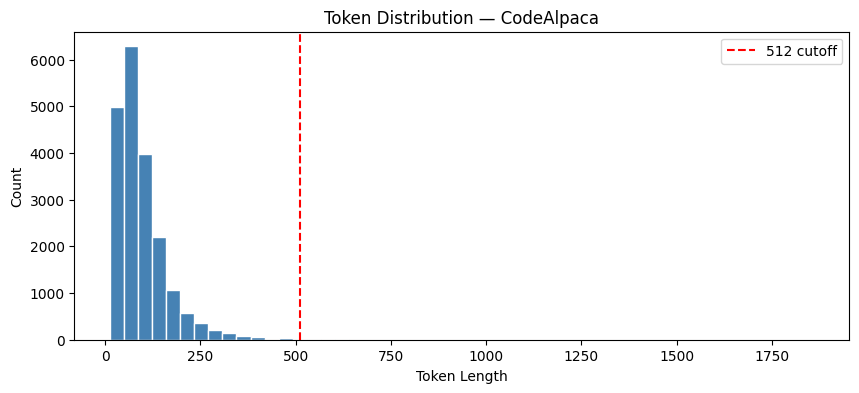

Min: 12 | Max: 1861 | Mean: 96


In [22]:
tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

def token_count(row):
    text = row["instruction"] + " " + row["input"] + " " + row["output"]
    # print(tokenizer(text))
    return len(tokenizer(text)["input_ids"])

lengths = [token_count(x) for x in cleaned]

plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color="steelblue", edgecolor="white")
plt.axvline(512, color="red", linestyle="--", label="512 cutoff")
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.title("Token Distribution — CodeAlpaca")
plt.legend()
plt.savefig("token_distribution.png", dpi=150)
plt.show()

print(f"Min: {min(lengths)} | Max: {max(lengths)} | Mean: {int(sum(lengths)/len(lengths))}")

### outlier removal and class balancing data

In [23]:
filtered = [x for x, l in zip(cleaned, lengths) if l <= 512]
print(f"After removing >512 token samples: {len(filtered)}")



buckets = {"qa": [], "reasoning": [], "extraction": []}
for x in filtered:
    buckets[x["type"]].append(x)


sampled = (
    buckets["reasoning"] +
    buckets["extraction"][:400] +
    buckets["qa"][:400]
)

random.seed(42)
random.shuffle(sampled)

print(Counter(x["type"] for x in sampled))

After removing >512 token samples: 19963
Counter({'qa': 400, 'extraction': 400, 'reasoning': 331})


### visualizing classes

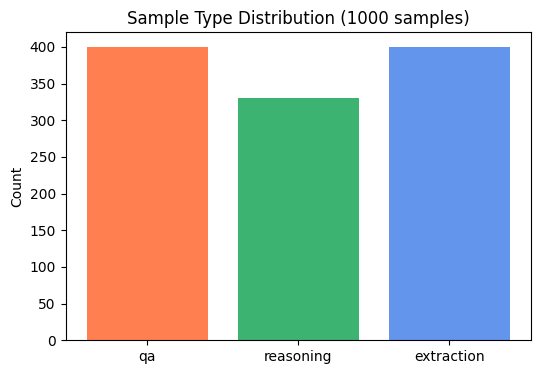

In [24]:
counts = Counter(x["type"] for x in sampled)

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["coral", "mediumseagreen", "cornflowerblue"])
plt.title("Sample Type Distribution (1000 samples)")
plt.ylabel("Count")
plt.savefig("type_distribution.png", dpi=150)
plt.show()

### train-test split

In [25]:
split = int(0.9 * len(sampled))
train_data = sampled[:split]
val_data = sampled[split:]

os.makedirs("data", exist_ok=True)

def save_jsonl(data, path):
    with open(path, "w") as f:
        for row in data:
            f.write(json.dumps(row) + "\n")

save_jsonl(train_data, "data/train.jsonl")
save_jsonl(val_data, "data/val.jsonl")

print(f"Train: {len(train_data)} | Val: {len(val_data)}")

Train: 1017 | Val: 114
